# DISCO vs Baselines in S-mode

Benchmark of DISCO against baseline methods when both are evaluated with secure (S-mode) counterfactuals.

This notebook reuses the synthetic scenario bundle and compares how well each method reproduces the oracle (population simplex) treatment-effect curve across many interventions and query points.

In [2]:
# Add repository root to the Python path
import sys
import os
sys.path.append(os.path.abspath('../..'))


In [3]:
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple
import json
import math

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from disco.synth.generator import SyntheticScenario
from disco.explain.disco_algorithm import DiscoRunner
from disco.explain.baselines import BaselineRunner
from disco.explain.te_curve import Explainer
from disco.interventions.tabular import FeatureAdd, ClampedShift
from disco.interventions.grids import Grids
from disco.cli.main import compute_probe_trajectories, load_devices
from disco.matching.weights import WeightSolver


In [4]:
# Helper utilities
def load_scenario_bundle(scenario_dir: Path):
    """Load scenario assets plus any precomputed probe trajectories."""
    scenario = SyntheticScenario.load(scenario_dir / 'scenario.npz')
    trajectories: Dict[Tuple[str, str], np.ndarray] = {}
    sample_rows = None
    probes_dir = scenario_dir / 'probes'
    if probes_dir.exists():
        for npy_path in probes_dir.glob('*.npy'):
            if npy_path.name == 'X_probe.npy':
                continue
            parts = npy_path.stem.split('_', 2)
            if len(parts) < 3:
                continue
            device_id = f"{parts[0]}_{parts[1]}"
            interv_name = '_'.join(parts[2:])
            data = np.load(npy_path)
            trajectories[(device_id, interv_name)] = data
            if sample_rows is None:
                sample_rows = data.shape[0]
    X_probe = scenario.X_probe
    if sample_rows is not None and sample_rows < len(X_probe):
        X_probe = X_probe[:sample_rows]
    return scenario, trajectories, X_probe


def summarise_feature_bounds(X: np.ndarray) -> Dict[int, Tuple[float, float]]:
    """Empirical 5th/95th percentiles per feature for clamping."""
    bounds = {}
    for idx in range(X.shape[1]):
        lower, upper = np.percentile(X[:, idx], [5, 95])
        bounds[idx] = (float(lower), float(upper))
    return bounds


def sample_random_interventions(
    n_interventions: int,
    X_probe: np.ndarray,
    theta_post: np.ndarray,
    rng: np.random.Generator,
) -> List:
    """Generate a diverse intervention set."""
    bounds = summarise_feature_bounds(X_probe)
    interventions = []
    used_names = set()
    feature_dim = X_probe.shape[1]
    for idx in range(n_interventions):
        kind = rng.choice(['intensity_add', 'feature_add', 'clamped_shift'])
        if kind == 'intensity_add':
            scale = float(rng.uniform(0.6, 1.2))
            delta_max = float(theta_post[-1] * scale)
            name = f"intensity_shift_{idx:03d}"
            intervention = FeatureAdd(
                feat_idx=0,
                delta_max=delta_max,
                name=name,
            )
        elif kind == 'feature_add':
            feat_idx = int(rng.integers(1, feature_dim))
            delta_max = float(theta_post[-1])
            name = f"add_f{feat_idx}_{idx:03d}"
            intervention = FeatureAdd(
                feat_idx=feat_idx,
                delta_max=delta_max,
                clamp=(-3.0, 3.0),
                name=name,
            )
        else:
            feat_idx = int(rng.integers(1, feature_dim))
            lower, upper = bounds.get(feat_idx, (-3.0, 3.0))
            if not np.isfinite(lower) or not np.isfinite(upper) or abs(upper - lower) < 1e-3:
                lower, upper = -3.0, 3.0
            shift_max = float(rng.uniform(0.4, 1.0))
            name = f"clamped_f{feat_idx}_{idx:03d}"
            intervention = ClampedShift(
                feat_idx=feat_idx,
                shift_max=shift_max,
                lower=lower,
                upper=upper,
                name=name,
            )
        if intervention.name in used_names:
            intervention.name = f"{intervention.name}_{idx}"
        used_names.add(intervention.name)
        interventions.append(intervention)
    return interventions


def compute_curve_metrics(tau_hat: np.ndarray, tau_true: np.ndarray, theta: np.ndarray) -> Dict[str, float]:
    diff = tau_hat - tau_true
    abs_diff = np.abs(diff)
    metrics = {
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'mae': float(abs_diff.mean()),
        'max_abs': float(abs_diff.max()),
        'auc_abs_diff': float(np.trapz(abs_diff, theta)),
    }
    return metrics


def to_serialisable(meta: Dict) -> Dict:
    if meta is None:
        return {}
    serialised = {}
    for key, value in meta.items():
        if isinstance(value, np.generic):
            serialised[key] = value.item()
        elif isinstance(value, np.ndarray):
            serialised[key] = value.tolist()
        else:
            serialised[key] = value
    return serialised


In [5]:
# Load scenario assets and configure experiment
SCENARIO_DIR = Path('..').resolve() / 'results' / 'synth_run'
MODEL_DIR = Path('..').resolve() / 'synth_devices'

scenario, scenario_trajs, scenario_X_probe = load_scenario_bundle(SCENARIO_DIR)
model_devices = load_devices(str(MODEL_DIR))

print(f"Oracle devices: {len(scenario.devices)}")
print(f"Model devices: {len(model_devices)}")

grids = Grids(theta0=scenario.theta0, theta=scenario.theta)
theta_post = grids.theta

target_idx = 0
target_device = model_devices[target_idx]
target_class = 0 if getattr(target_device, 'task', 'regression') != 'classification' else 1

rng = np.random.default_rng(42)
N_INTERVENTIONS = 10
N_QUERIES = 20

interventions = sample_random_interventions(N_INTERVENTIONS, scenario_X_probe, theta_post, rng)
print(f"Sampled {len(interventions)} interventions. First five: {[interv.name for interv in interventions[:5]]}")


Oracle devices: 10
Model devices: 10
Sampled 10 interventions. First five: ['intensity_shift_000', 'clamped_f4_001', 'clamped_f2_002', 'intensity_shift_003', 'clamped_f8_004']


In [6]:
# Pre-compute probe trajectories for the intervention set
probe_trajectories_model = compute_probe_trajectories(
    devices=model_devices,
    X_probe=scenario_X_probe,
    interventions=interventions,
    theta0=grids.theta0,
    dp_noise_std=0.0,
    seed=0,
    target_class=target_class,
)
probe_trajectories_oracle = compute_probe_trajectories(
    devices=scenario.devices,
    X_probe=scenario_X_probe,
    interventions=interventions,
    theta0=grids.theta0,
    dp_noise_std=0.0,
    seed=0,
    target_class=target_class,
)
print(f"Computed {len(probe_trajectories_model)} model trajectory tensors and {len(probe_trajectories_oracle)} oracle tensors")

trajectories_model_by_intervention: Dict[str, Dict[Tuple[str, str], np.ndarray]] = {}
trajectories_oracle_by_intervention: Dict[str, Dict[Tuple[str, str], np.ndarray]] = {}
for intervention in interventions:
    name = intervention.name
    trajectories_model_by_intervention[name] = {
        key: value for key, value in probe_trajectories_model.items() if key[1] == name
    }
    trajectories_oracle_by_intervention[name] = {
        key: value for key, value in probe_trajectories_oracle.items() if key[1] == name
    }

if N_QUERIES > len(scenario_X_probe):
    raise ValueError(f"Requested {N_QUERIES} queries but only {len(scenario_X_probe)} probes available")
query_indices = rng.choice(len(scenario_X_probe), size=N_QUERIES, replace=False)
query_points = scenario_X_probe[query_indices]
print(f"Selected {len(query_points)} query points from the probe pool")


Computed 100 model trajectory tensors and 100 oracle tensors
Selected 20 query points from the probe pool


In [7]:
# Instantiate runners
disco_runner = DiscoRunner(mode='s', explainer=Explainer(compute_flip=False))
baseline_runner = BaselineRunner(explainer=Explainer(compute_flip=False))
global_weight_solver = WeightSolver(method='projected_grad', max_iter=2000)


In [ ]:
# Benchmark loop: DISCO vs baselines for every (intervention, query)
theta_vec = grids.theta
records = []
failure_log = defaultdict(list)

for intervention in tqdm(interventions, desc='Interventions'):
    traj_slice_model = trajectories_model_by_intervention[intervention.name]
    traj_slice_oracle = trajectories_oracle_by_intervention[intervention.name]
    for local_idx, probe_idx in enumerate(query_indices):
        x_star = scenario_X_probe[probe_idx:probe_idx + 1]

        try:
            disco_output = disco_runner.run(
                devices=model_devices,
                target_idx=target_idx,
                x_star=x_star,
                X_probe=scenario_X_probe,
                trajectories=traj_slice_model,
                grids=grids,
                intervention=intervention,
                target_class=target_class,
                mode='s',
                lam=0.01,
            )
        except Exception as exc:
            failure_log['disco'].append((intervention.name, int(probe_idx), str(exc)))
            continue

        disco_te = disco_output.te_output
        disco_tau = disco_te.tau
        disco_diag = disco_output.diagnostics
        disco_meta = {key: disco_diag.get(key) for key in ['eps_pre', 'anchor_radius', 'proxy_bias', 'weight_sparsity', 'n_effective_peers']}
        anchor_sel = disco_diag.get('anchor_selection')

        oracle_output = baseline_runner.baseline_oracle_ground_truth(
            devices=model_devices,
            trajectories=traj_slice_model,
            theta0=grids.theta0,
            x_star=x_star,
            grids=grids,
            intervention=intervention,
            target_idx=target_idx,
            target_class=target_class,
            oracle_devices=scenario.devices,
            oracle_trajectories=traj_slice_oracle,
            oracle_theta0=grids.theta0,
        )
        tau_true = oracle_output.tau

        method_curves = {
            'disco': (disco_tau, disco_meta),
            'oracle_w': (tau_true, oracle_output.meta),
        }

        try:
            avg_output = baseline_runner.baseline_avg(
                devices=model_devices,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_idx=target_idx,
                target_class=target_class,
            )
            method_curves['avg'] = (avg_output.tau, avg_output.meta)
        except Exception as exc:
            failure_log['avg'].append((intervention.name, int(probe_idx), str(exc)))

        if anchor_sel is not None:
            try:
                topk_output = baseline_runner.baseline_topk_avg(
                    devices=model_devices,
                    trajectories=traj_slice_model,
                    anchor_sel=anchor_sel,
                    theta0=grids.theta0,
                    x_star=x_star,
                    grids=grids,
                    intervention=intervention,
                    target_idx=target_idx,
                    Kp=5,
                    target_class=target_class,
                )
                method_curves['topk'] = (topk_output.tau, topk_output.meta)
            except Exception as exc:
                failure_log['topk'].append((intervention.name, int(probe_idx), str(exc)))

            try:
                ridge_output = baseline_runner.baseline_unconstrained_ridge(
                    devices=model_devices,
                    trajectories=traj_slice_model,
                    anchor_sel=anchor_sel,
                    theta0=grids.theta0,
                    x_star=x_star,
                    grids=grids,
                    intervention=intervention,
                    target_idx=target_idx,
                    lam=0.01,
                    target_class=target_class,
                )
                method_curves['unconstrained_ridge'] = (ridge_output.tau, ridge_output.meta)
            except Exception as exc:
                failure_log['unconstrained_ridge'].append((intervention.name, int(probe_idx), str(exc)))

        try:
            glob_output = baseline_runner.baseline_glob_matching(
                devices=model_devices,
                trajectories=traj_slice_model,
                theta0=grids.theta0,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_idx=target_idx,
                weight_solver=global_weight_solver,
                target_class=target_class,
            )
            method_curves['glob_matching'] = (glob_output.tau, glob_output.meta)
        except Exception as exc:
            failure_log['glob_matching'].append((intervention.name, int(probe_idx), str(exc)))

        try:
            lp_output = baseline_runner.baseline_local_perturbation(
                device_t=target_device,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_class=target_class,
            )
            method_curves['local_perturbation'] = (lp_output.tau, lp_output.meta)
        except Exception as exc:
            failure_log['local_perturbation'].append((intervention.name, int(probe_idx), str(exc)))

        tau_true_auc = float(np.trapz(np.abs(tau_true), theta_vec))
        tau_true_energy = float(np.sqrt(np.mean(tau_true ** 2)))

        for method_name, (tau_hat, meta) in method_curves.items():
            metrics = compute_curve_metrics(tau_hat, tau_true, theta_vec)
            record = {
                'method': method_name,
                'intervention': intervention.name,
                'query_index': int(local_idx),
                'probe_index': int(probe_idx),
                'tau_true_auc': tau_true_auc,
                'tau_true_energy': tau_true_energy,
            }
            record.update(metrics)
            if method_name == 'disco':
                for key, value in disco_meta.items():
                    record[f'disco_{key}'] = value
            record['meta'] = json.dumps(to_serialisable(meta))
            records.append(record)

failure_summary = {name: len(entries) for name, entries in failure_log.items() if entries}
print('Failure summary:', failure_summary if failure_summary else 'None')

results_df = pd.DataFrame.from_records(records)
print(f"Collected {len(results_df)} method evaluations")


Interventions:   0%|          | 0/10 [00:00<?, ?it/s]

In [43]:
# Aggregate metrics with standard errors
metric_cols = ['rmse', 'mae', 'max_abs', 'auc_abs_diff']
summary = (
    results_df
    .groupby('method')[metric_cols]
    .agg(['mean', 'std', 'count'])
)

for metric in metric_cols:
    summary[(metric, 'sem')] = summary[(metric, 'std')] / np.sqrt(summary[(metric, 'count')].clip(lower=1))

summary = summary.sort_values(('rmse', 'mean'))
summary.columns = ['{}_{}'.format(col[0], col[1]) for col in summary.columns]
summary = summary.reset_index()
summary


,method,rmse_mean,rmse_std,rmse_count,mae_mean,mae_std,mae_count,max_abs_mean,max_abs_std,max_abs_count,auc_abs_diff_mean,auc_abs_diff_std,auc_abs_diff_count,rmse_sem,mae_sem,max_abs_sem,auc_abs_diff_sem
0,oracle_w,0.000000,0.000000,200,0.000000,0.000000,200,0.000000,0.000000,200,0.000000,0.000000,200,0.000000,0.000000,0.000000,0.000000
1,topk,0.439830,0.579020,200,0.404295,0.523404,200,0.652510,0.929527,200,0.329368,0.429893,200,0.040943,0.037010,0.065727,0.030398
2,disco,0.465922,0.625986,200,0.429113,0.567554,200,0.691712,0.997180,200,0.350073,0.466169,200,0.044264,0.040132,0.070511,0.032963
3,unconstrained_ridge,0.470440,0.622451,200,0.432730,0.565265,200,0.697621,0.991283,200,0.352883,0.464073,200,0.044014,0.039970,0.070094,0.032815
4,glob_matching,0.471109,0.613899,200,0.434663,0.555222,200,0.695236,0.984553,200,0.354384,0.456231,200,0.043409,0.039260,0.069618,0.032260
5,local_perturbation,0.502579,0.613967,200,0.463449,0.556005,200,0.731800,0.971985,200,0.377751,0.455745,200,0.043414,0.039316,0.068730,0.032226
6,avg,0.509195,0.583986,200,0.475713,0.532394,200,0.729762,0.935327,200,0.386551,0.436195,200,0.041294,0.037646,0.066138,0.030844


In [44]:
# Tabular view of mean +/- standard error
def format_mean_sem(row, metric):
    return f"{row[f'{metric}_mean']:.4f} +/- {row[f'{metric}_sem']:.4f}"

formatted_table = pd.DataFrame({
    metric: summary.apply(lambda row, m=metric: format_mean_sem(row, m), axis=1)
    for metric in ['rmse', 'mae', 'max_abs', 'auc_abs_diff']
})
formatted_table.insert(0, 'method', summary['method'])
formatted_table


,method,rmse,mae,max_abs,auc_abs_diff
0,oracle_w,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.0000 +/- 0.0000
1,topk,0.4398 +/- 0.0409,0.4043 +/- 0.0370,0.6525 +/- 0.0657,0.3294 +/- 0.0304
2,disco,0.4659 +/- 0.0443,0.4291 +/- 0.0401,0.6917 +/- 0.0705,0.3501 +/- 0.0330
3,unconstrained_ridge,0.4704 +/- 0.0440,0.4327 +/- 0.0400,0.6976 +/- 0.0701,0.3529 +/- 0.0328
4,glob_matching,0.4711 +/- 0.0434,0.4347 +/- 0.0393,0.6952 +/- 0.0696,0.3544 +/- 0.0323
5,local_perturbation,0.5026 +/- 0.0434,0.4634 +/- 0.0393,0.7318 +/- 0.0687,0.3778 +/- 0.0322
6,avg,0.5092 +/- 0.0413,0.4757 +/- 0.0376,0.7298 +/- 0.0661,0.3866 +/- 0.0308


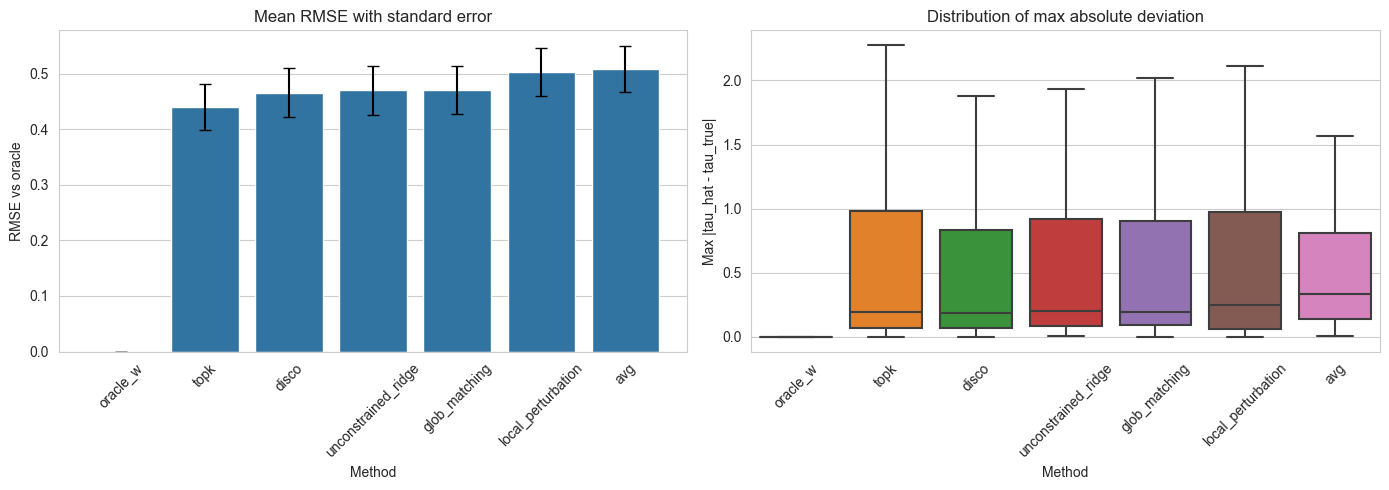

In [45]:
# Visual comparisons
sns.set_style('whitegrid')
order = summary.sort_values('rmse_mean')['method']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bar_data = summary.set_index('method').loc[order].reset_index()
sns.barplot(data=bar_data, x='method', y='rmse_mean', ax=ax, color='C0')
yerr = bar_data['rmse_sem']
ax.errorbar(range(len(bar_data)), bar_data['rmse_mean'], yerr=yerr, fmt='none', c='black', capsize=4)
ax.set_ylabel('RMSE vs oracle')
ax.set_xlabel('Method')
ax.set_title('Mean RMSE with standard error')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
sample_df = results_df[results_df['method'].isin(order)]
sns.boxplot(data=sample_df, x='method', y='max_abs', ax=ax, order=order, showfliers=False)
ax.set_ylabel('Max |tau_hat - tau_true|')
ax.set_xlabel('Method')
ax.set_title('Distribution of max absolute deviation')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()


In [11]:
# Optional: relative performance vs DISCO
pivot_metrics = results_df.pivot_table(
    index=['intervention', 'query_index'],
    columns='method',
    values='rmse'
)
if 'disco' in pivot_metrics.columns:
    diff_vs_disco = pivot_metrics.subtract(pivot_metrics['disco'], axis=0)
    rel_summary = diff_vs_disco.mean().sort_values()
    rel_summary
else:
    print('DISCO results missing from pivot table; skipping relative summary.')
